# 02 피처 EDA


In [1]:
import os
from pathlib import Path
import warnings

# 프로젝트 경로 고정
PROJECT_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects")
DATA_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data")
OUTPUT_DIR = PROJECT_DIR / "outputs" / "02_eda_feature_review"

# matplotlib 시각화 환경 안정화
MPLCONFIG_DIR = PROJECT_DIR / ".mplconfig"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")

FEAT_PATH = DATA_DIR / "sub_upbit_eth_min_feature_labels.pkl"

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"FEAT_PATH exists: {FEAT_PATH.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


PROJECT_DIR: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects
FEAT_PATH exists: True
OUTPUT_DIR: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects/outputs/02_eda_feature_review


## 1. 피처 구조 파악

- 기존 pkl 파일의 컬럼 구성 확인
- 피처를 역할별로 그룹화


In [2]:
# feature 파일 로드 -> 시계열 인덱스 준비
feat = pd.read_pickle(FEAT_PATH).sort_index().copy()
feat.index = pd.to_datetime(feat.index)

# 피처를 역할별로 그룹화
feature_groups = {
    "price_level": ["open", "high", "low", "close"],
    "volume": ["volume", "volume_cmf", "volume_fi", "volume_mfi", "volume_sma_em", "volume_vpt"],
    "volatility": ["volatility_atr", "volatility_ui", "std_30", "vol_std_30"],
    "trend": ["trend_macd_diff", "trend_adx", "trend_trix", "trend_mass_index", "trend_dpo", "trend_aroon_ind"],
    "momentum": ["momentum_rsi", "momentum_wr"],
    "return": ["vol_change_5", "ret_5", "vol_change_10", "ret_10", "vol_change_20", "ret_20"],
    "label": ["t_value"],
}

# 컬럼-역할 대응표
catalog_rows = []
for group_name, columns in feature_groups.items():
    for column in columns:
        catalog_rows.append({"group": group_name, "feature": column})

feature_catalog = pd.DataFrame(catalog_rows)
group_count = feature_catalog.groupby("group").size().rename("feature_count").reset_index()

feature_basic_summary = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "column_count",
            "start_time",
            "end_time",
            "feature_count_without_label",
            "label_count",
        ],
        "value": [
            len(feat),
            feat.shape[1],
            feat.index.min(),
            feat.index.max(),
            feat.shape[1] - 1,
            feat["t_value"].nunique(),
        ],
    }
)

feature_catalog.to_csv(OUTPUT_DIR / "feature_catalog.csv", index=False)
feature_basic_summary.to_csv(OUTPUT_DIR / "feature_basic_summary.csv", index=False)

display(feature_basic_summary)
display(group_count)
display(feature_catalog)


,metric,value
0,row_count,908845
1,column_count,29
2,start_time,2018-01-01 00:43:00
3,end_time,2019-11-03 10:03:00
4,feature_count_without_label,28
5,label_count,3


,group,feature_count
0,label,1
1,momentum,2
2,price_level,4
3,return,6
4,trend,6
5,volatility,4
6,volume,6


,group,feature
0,price_level,open
1,price_level,high
2,price_level,low
3,price_level,close
4,volume,volume
5,volume,volume_cmf
6,volume,volume_fi
7,volume,volume_mfi
8,volume,volume_sma_em
9,volume,volume_vpt


- 전체 피처는 `price_level / volume / volatility / trend / momentum / return / label` 구조로 정리 가능
- 원시 가격과 파생 피처가 같이 있어 스케일 차이가 크므로 해석과 모델링에서 분리해서 보는 것이 안전


## 2. 월별 Drift와 Label 비중 변화

- 월별 중앙값 기준 drift 확인
- 월별 `t_value` 비중 변화 확인


In [3]:
# label 제외 feature 목록
features = [column for column in feat.columns if column != "t_value"]

# 월별 중앙값 사용 -> 극단값 영향 완화
monthly_feature_median = feat[features].resample("ME").median()

# drift score: 월별 중앙값이 전체 중앙값에서 얼마나 벗어나는지
overall_median = feat[features].median()
overall_std = feat[features].std().replace(0, np.nan)
monthly_feature_z = (monthly_feature_median - overall_median) / overall_std
feature_drift_score = monthly_feature_z.abs().mean().sort_values(ascending=False).rename("avg_abs_monthly_z").to_frame()

# 월별 `t_value` 비중 확인
monthly_t_value_ratio = feat.groupby([pd.Grouper(freq="ME"), "t_value"]).size().unstack(fill_value=0)
monthly_t_value_ratio = monthly_t_value_ratio.div(monthly_t_value_ratio.sum(axis=1), axis=0)

# 대표 feature만 따로 확인
representative_features = ["ret_10", "momentum_rsi", "trend_macd_diff", "std_30", "vol_std_30", "volatility_atr"]
representative_monthly = monthly_feature_median[representative_features].copy()

monthly_feature_median.to_csv(OUTPUT_DIR / "monthly_feature_median.csv")
monthly_t_value_ratio.to_csv(OUTPUT_DIR / "monthly_t_value_ratio.csv")
feature_drift_score.to_csv(OUTPUT_DIR / "feature_drift_score.csv")

display(feature_drift_score.head(10))
display(monthly_t_value_ratio.head())
display(representative_monthly.head())


,avg_abs_monthly_z
low,0.586576
open,0.586175
close,0.586175
high,0.585835
volatility_atr,0.251295
std_30,0.214446
vol_std_30,0.177420
volatility_ui,0.168342
trend_aroon_ind,0.166883
volume_cmf,0.094235


t_value,-1.000000,-0.000000,1.000000
time,,,
2018-01-31,0.336329,0.291461,0.372210
2018-02-28,0.336988,0.304902,0.358110
2018-03-31,0.364062,0.323922,0.312016
2018-04-30,0.288417,0.329599,0.381984
2018-05-31,0.325204,0.316218,0.358578


,ret_10,momentum_rsi,trend_macd_diff,std_30,vol_std_30,volatility_atr
time,,,,,,
2018-01-31,0.000267,50.632443,9.722447,"5,876.213495",43.102940,"4,083.579638"
2018-02-28,0.000000,50.235404,-0.844642,"2,638.892345",30.422075,"1,649.071189"
2018-03-31,-0.000106,48.943205,-4.301535,"1,599.946096",17.545822,937.357976
2018-04-30,0.000145,51.165014,-3.078860,"1,133.076337",25.605111,811.808672
2018-05-31,0.000000,50.351472,-0.105874,"1,604.720025",23.338928,"1,153.012305"


- 가격 레벨 feature의 drift가 가장 크고, 파생 피처 중에는 변동성 계열 drift가 상대적으로 큼
- 월별 `t_value` 비중도 고정되지 않아 시기별 분포 이동이 존재
- 따라서 `time-based split`과 월별 성능 비교가 필요


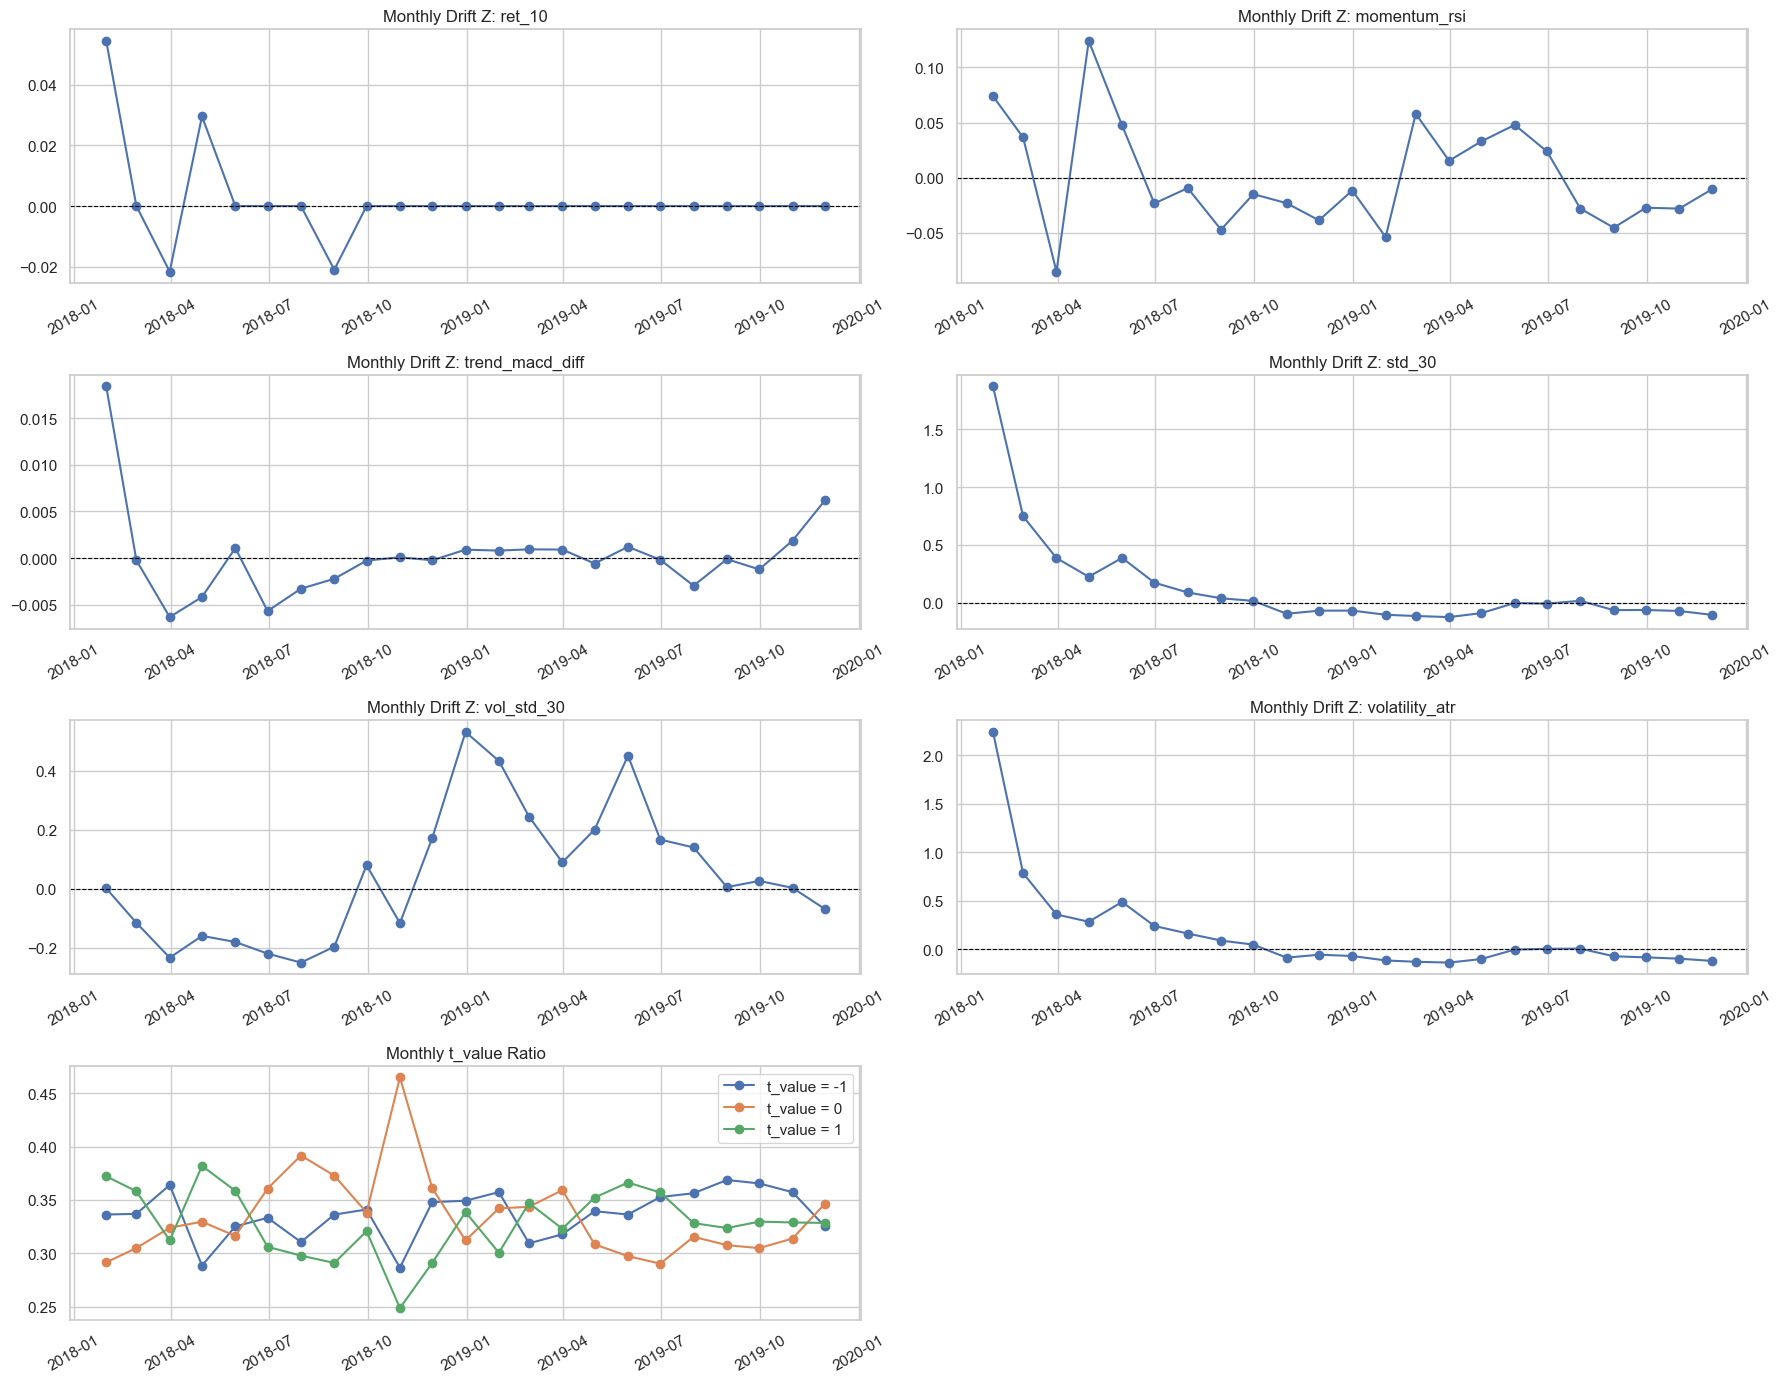

In [4]:
# 표준화된 drift 그래프
plot_feature_z = monthly_feature_z[representative_features].copy()

fig, axes = plt.subplots(4, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, column in zip(axes[:6], representative_features):
    ax.plot(plot_feature_z.index, plot_feature_z[column], marker="o", linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"Monthly Drift Z: {column}")
    ax.tick_params(axis="x", rotation=30)

# 마지막 축 -> 월별 라벨 비중
axes[6].plot(monthly_t_value_ratio.index, monthly_t_value_ratio[-1.0], label="t_value = -1", marker="o")
axes[6].plot(monthly_t_value_ratio.index, monthly_t_value_ratio[-0.0], label="t_value = 0", marker="o")
axes[6].plot(monthly_t_value_ratio.index, monthly_t_value_ratio[1.0], label="t_value = 1", marker="o")
axes[6].set_title("Monthly t_value Ratio")
axes[6].tick_params(axis="x", rotation=30)
axes[6].legend()

# 남는 축은 숨김
axes[7].axis("off")

plt.tight_layout()
plt.show()


- `ret_10`은 상대적으로 안정적이지만 `std_30`, `volatility_atr`, `trend_macd_diff`는 월별 변화가 큼
- 모든 피처를 정적 분포로 가정하면 시기별 성능이 흔들릴 수 있음
- 수익률 계열처럼 비교적 안정적인 피처를 우선 검토하는 것이 유리


## 3. 상관구조와 중복 피처

- 어떤 feature가 사실상 같은 정보를 담는지 확인
- 대표 변수만 남길 후보 찾기


In [5]:
# redundancy: 너무 비슷한 feature가 함께 있는 상태

all_features = [column for column in feat.columns if column != "t_value"]
engineered_features = [column for column in all_features if column not in ["open", "high", "low", "close", "volume"]]

def get_top_corr_pairs(dataframe):
    corr_matrix = dataframe.corr().abs()
    upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
    top_pairs = (
        corr_matrix.mask(upper_mask)
        .stack()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "abs_corr"})
    )
    return top_pairs

top_corr_pairs_all = get_top_corr_pairs(feat[all_features])
top_corr_pairs_engineered = get_top_corr_pairs(feat[engineered_features])

top_corr_pairs_all.to_csv(OUTPUT_DIR / "top_corr_pairs_all.csv", index=False)
top_corr_pairs_engineered.to_csv(OUTPUT_DIR / "top_corr_pairs_engineered.csv", index=False)

display(top_corr_pairs_all.head(10))
display(top_corr_pairs_engineered.head(10))


,feature_a,feature_b,abs_corr
0,close,high,0.999994
1,low,open,0.999994
2,close,low,0.999994
3,high,open,0.999994
4,close,open,0.999991
5,low,high,0.999988
6,std_30,volatility_atr,0.923114
7,momentum_wr,momentum_rsi,0.780165
8,ret_20,trend_trix,0.735408
9,momentum_rsi,trend_aroon_ind,0.718171


,feature_a,feature_b,abs_corr
0,std_30,volatility_atr,0.923114
1,momentum_wr,momentum_rsi,0.780165
2,ret_20,trend_trix,0.735408
3,momentum_rsi,trend_aroon_ind,0.718171
4,ret_10,ret_5,0.695265
5,ret_20,ret_10,0.687257
6,ret_10,trend_macd_diff,0.676908
7,ret_20,momentum_rsi,0.672820
8,momentum_rsi,volume_mfi,0.641742
9,std_30,volatility_ui,0.641560


- `open/high/low/close`는 거의 같은 축으로 움직여 사실상 중복 정보에 가까움
- 파생 피처도 `std_30-volatility_atr`, `momentum_wr-momentum_rsi`처럼 상관이 높은 쌍이 존재
- 따라서 상관계수 기반 제거 또는 그룹별 대표 변수 선정이 필요


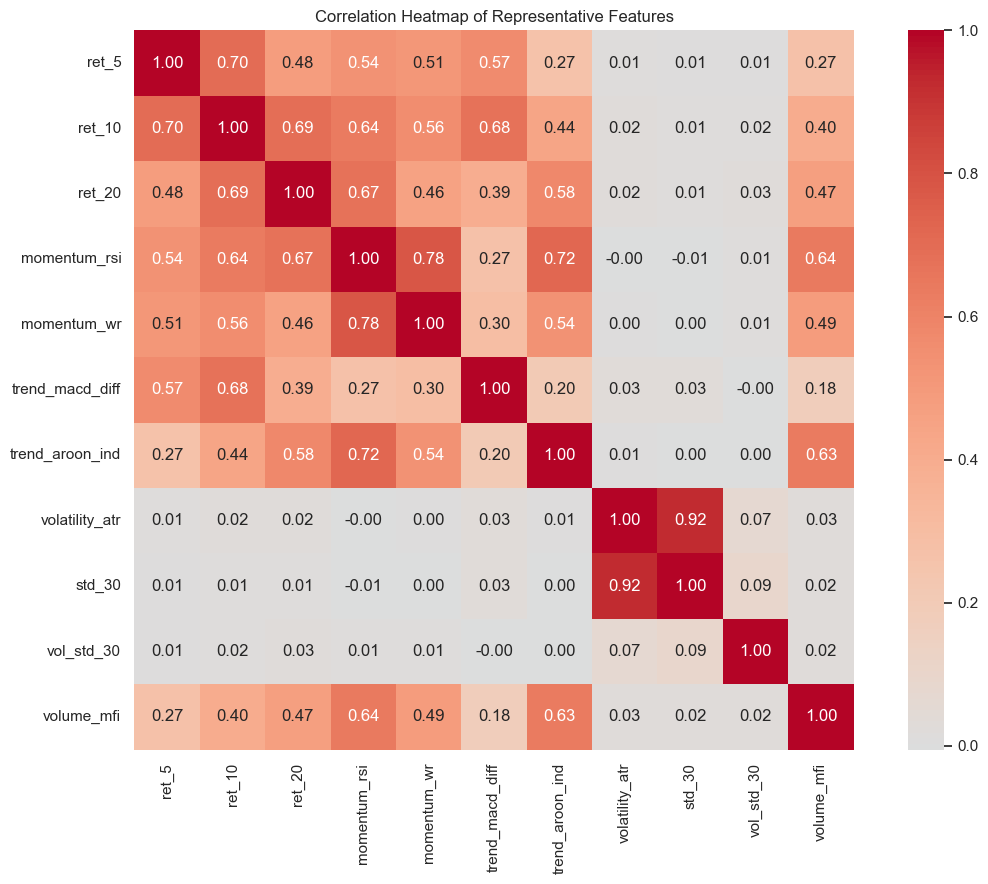

In [6]:
# 대표 파생 feature heatmap
heatmap_features = [
    "ret_5",
    "ret_10",
    "ret_20",
    "momentum_rsi",
    "momentum_wr",
    "trend_macd_diff",
    "trend_aroon_ind",
    "volatility_atr",
    "std_30",
    "vol_std_30",
    "volume_mfi",
]

corr_selected = feat[heatmap_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_selected, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap of Representative Features")
plt.tight_layout()
plt.show()


- heatmap에서 `return-momentum-trend` 계열이 함께 묶이고 `volatility` 계열도 별도 덩어리를 형성
- 피처 수는 많아 보여도 실제 정보 축은 더 적을 수 있음
- 차원 축소나 대표 변수 선택만으로도 충분히 단순화할 여지가 있음


## 4. Label Separability

- `t_value`와 잘 갈리는 feature 확인
- 방향성 피처와 변동성 피처의 역할 차이 확인


In [7]:
# separability: 라벨별 feature 분리 정도
# Spearman + ANOVA F로 확인

model_features = [column for column in feat.columns if column not in ["t_value", "open", "high", "low", "close"]]
target = feat["t_value"]

def compute_anova_f(feature_series, label_series):
    temp = pd.DataFrame({"x": feature_series, "y": label_series})
    groups = [group_df["x"].values for _, group_df in temp.groupby("y")]
    group_sizes = [len(group) for group in groups]
    group_means = [group.mean() for group in groups]
    overall_mean = temp["x"].mean()
    k = len(groups)
    n = len(temp)
    ss_between = sum(size * (mean - overall_mean) ** 2 for size, mean in zip(group_sizes, group_means))
    ss_within = sum(((group - group.mean()) ** 2).sum() for group in groups)
    if ss_within == 0:
        return np.nan
    return (ss_between / (k - 1)) / (ss_within / (n - k))

separability_rows = []
for column in model_features:
    spearman_value = feat[column].corr(target, method="spearman")
    anova_f_value = compute_anova_f(feat[column], target)
    separability_rows.append(
        {
            "feature": column,
            "spearman_to_t_value": spearman_value,
            "anova_f": anova_f_value,
        }
    )

feature_separability_rank = pd.DataFrame(separability_rows).sort_values(
    ["anova_f", "spearman_to_t_value"],
    ascending=False,
)

# 상위 feature의 클래스별 평균/중앙값
top_separable_features = feature_separability_rank.head(6)["feature"].tolist()
class_summary_selected_features = feat.groupby("t_value")[top_separable_features].agg(["mean", "median"])

feature_separability_rank.to_csv(OUTPUT_DIR / "feature_separability_rank.csv", index=False)
class_summary_selected_features.to_csv(OUTPUT_DIR / "class_summary_selected_features.csv")

display(feature_separability_rank.head(12))
display(class_summary_selected_features)


,feature,spearman_to_t_value,anova_f
15,momentum_wr,0.323441,"53,256.544677"
14,momentum_rsi,0.311465,"50,750.611888"
19,ret_10,0.344892,"39,147.404040"
13,trend_aroon_ind,0.236434,"26,223.593062"
17,ret_5,0.279001,"25,701.843212"
3,volume_mfi,0.210446,"21,716.854895"
21,ret_20,0.244885,"19,626.466499"
8,trend_macd_diff,0.331911,"11,102.589436"
1,volume_cmf,0.114263,"6,093.284845"
12,trend_dpo,-0.202213,"4,450.286793"


momentum_wr            momentum_rsi              ret_10            \
                 mean     median         mean    median      mean    median   
t_value                                                                       
-1.000000  -63.874729 -69.565217    45.841346 46.250387 -0.001666 -0.000966   
-0.000000  -51.171441 -50.980392    49.916050 49.858725 -0.000026  0.000000   
1.000000   -38.065538 -33.333333    54.095098 53.586994  0.001718  0.000968   

          trend_aroon_ind                ret_5           volume_mfi            
                     mean     median      mean    median       mean    median  
t_value                                                                        
-1.000000      -17.448195 -35.000000 -0.000984 -0.000519  42.176489 40.990173  
-0.000000       -0.671753   5.000000 -0.000015  0.000000  47.860881 47.565315  
1.000000        16.092512  30.000000  0.001016  0.000504  53.697619 54.273719

- 상위 분리력은 `momentum_wr`, `momentum_rsi`, `ret_10`, `trend_aroon_ind`, `ret_5` 순으로 나타남
- 현재 `t_value`는 변동성보다 방향성과 모멘텀 정보를 더 많이 반영하는 라벨로 보임
- 기존 피처셋은 분류용으로는 유용하지만 이상탐지 목적에는 추가 설계가 필요


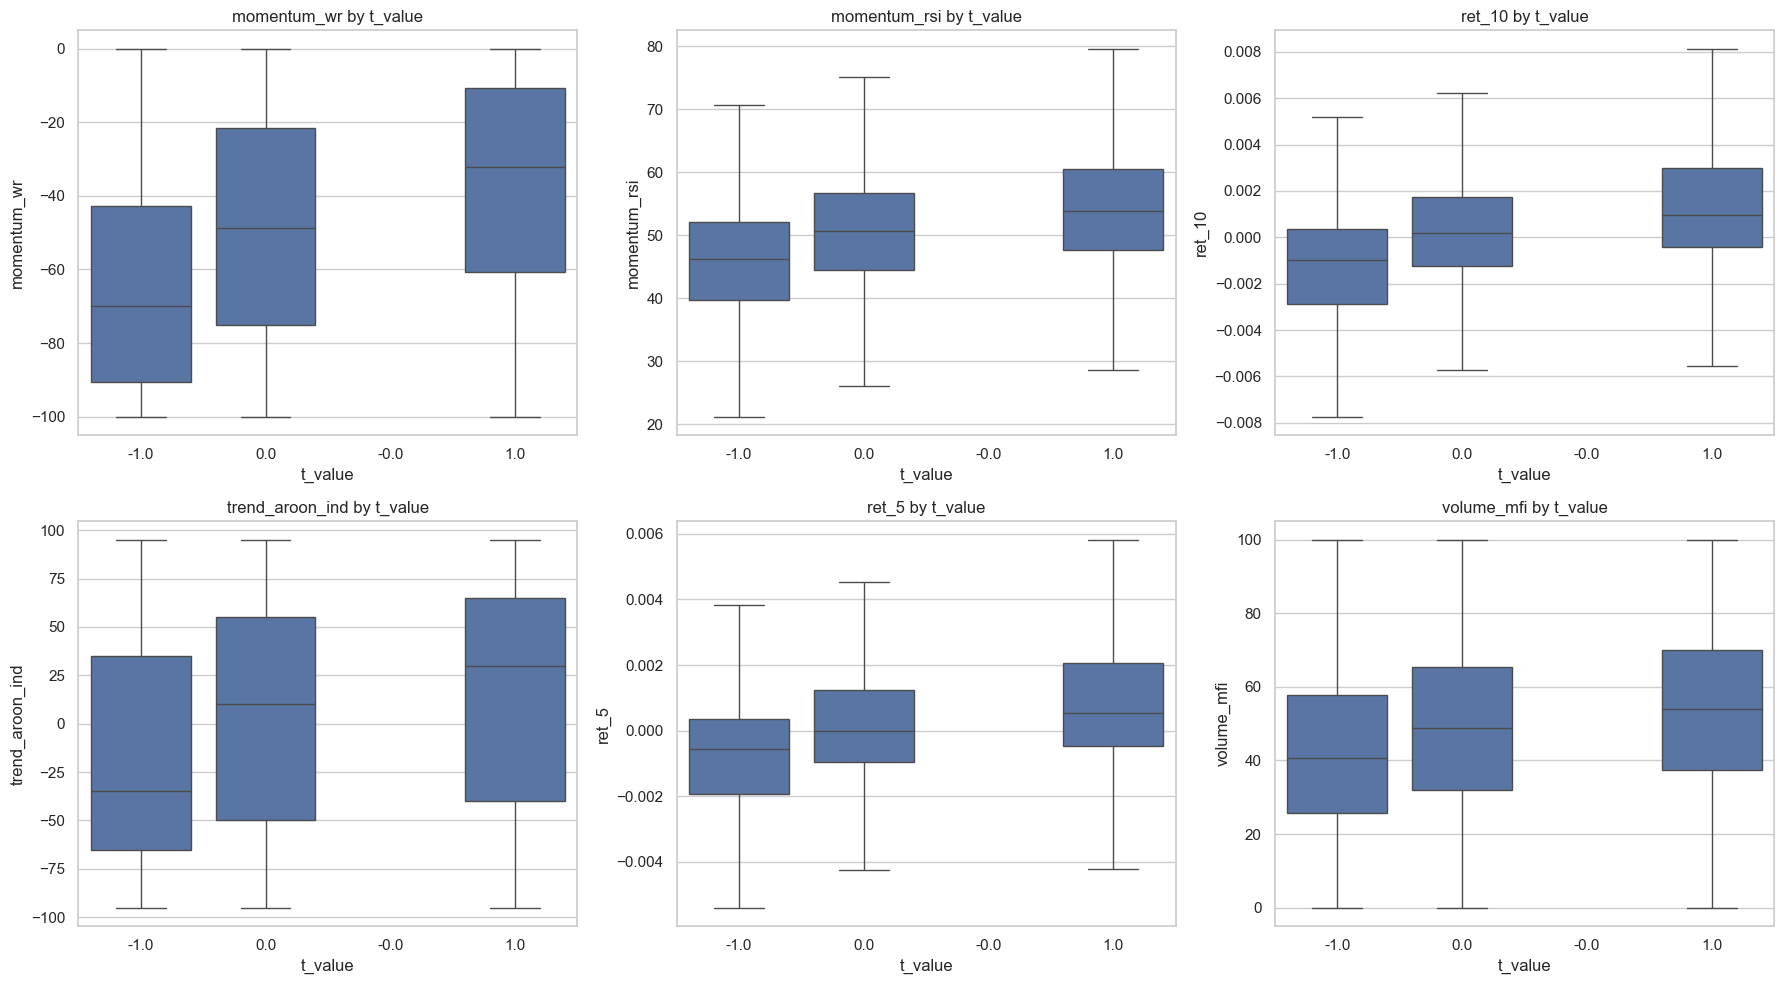

In [8]:
# 클래스별 분포 차이 확인
plot_sample = feat[top_separable_features + ["t_value"]].copy()
if len(plot_sample) > 20000:
    plot_sample = plot_sample.sample(20000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 극단값은 숨기고 중앙 분포만 확인
for ax, column in zip(axes, top_separable_features):
    sns.boxplot(data=plot_sample, x="t_value", y=column, ax=ax, showfliers=False)
    ax.set_title(f"{column} by t_value")

plt.tight_layout()
plt.show()


- boxplot에서도 `momentum_rsi`, `momentum_wr`, `ret_5`, `ret_10`은 `t_value`에 따라 비교적 자연스럽게 이동
- 반면 일부 피처는 클래스 간 겹침이 커 단일 feature만으로는 구분이 어려움
- 따라서 다변량 모델과 rule 기반 비교를 함께 가져가는 것이 적절
